# Agent-Based Model of Group Alignment

**How information propagates through a mixed-speed population of agents and humans.**

Yitian Chen · September 2026 · see `context.md` for the research brief.

---

## What this notebook does

Three claims from the brief, each turned into a runnable experiment:

| # | Claim | Experiment | Measured by |
|---|---|---|---|
| 1 | **Fast agents cluster** — agents interact mainly with each other | Sweep the speed ratio | `P(agent partner | agent initiator)` vs. the 50% baseline |
| 2 | **Fast information dominates** — agent-origin info drowns out human-origin info | Two regimes, one-shot vs. ongoing | Share of the population holding each origin |
| 3 | **Intervention restores balance** — biasing agents toward humans | Sweep two levers: the consultation bias `beta` (who agents ask) and the acceptance threshold `gamma` (how readily they believe it) | Dominance ratio, agent-origin ÷ human-origin |

Everything is built from small functions that take explicit parameters, so every knob
in the model can be changed from the `Params` object without editing any logic.

---

## The model in one page

**Bodies.** An `n × n` numpy array `society` of shape `(n, n, 2)`. Each cell is a
two-element list exactly as specified in the brief:

```
society[i, j] == [kind, X]

kind = 0  human            X = 0  holds no information
kind = 1  agent            X = 1  holds human-origin information
                           X = 2  holds agent-origin information
```

`kind` is fixed at initialisation; `X` is what evolves.

**The fingerprint travels with the information, not with the relayer.** `X` records
where a piece of information *originated*, and it is never re-stamped when it is passed
on. This is what makes `[1, 1]` — an **agent** holding **human-origin** information — a
legal and, for claim 3, a central state. If the tag were re-stamped by whoever last
relayed it, origin would be destroyed on the first cross-type hop and claims 2 and 3
would have nothing left to measure.

**Time.** Discrete ticks `t = 1 … T`. A body is *active* on tick `t` if
`(t + phase) % period == 0`. Agents have `period = 1` (active every tick); humans have
`period = 3` (active every third tick). Each body gets a fixed random `phase` at
initialisation so that humans do not all fire in lockstep — without it, all 5,000 humans
would act in unison on ticks 3, 6, 9 …, which is a synchronisation artifact rather than
a speed effect.

**One tick.** For every body simultaneously:

1. **Act** — the body is active if its period and phase say so.
2. **Consult** — an active body picks *one* of its four neighbours (the lattice wraps
   around, so there are no edge cases). The pick is uniform when `beta = 0`; `beta > 0`
   upweights *human* neighbours when the consulting body is an *agent*. **This is the
   claim-3 intervention, and it lives entirely in one function.**
3. **Respond** — the neighbour answers only if it is *also active this tick*. This
   mutual-availability requirement is the load-bearing assumption of the whole model:
   it makes contact rates scale as the *product* of the two speeds, so agent–agent
   contacts happen 9× more often than human–human ones with no homophily assumed
   anywhere. Setting `gate_acceptance = False` removes it, and is the control that
   should make claim 1 disappear.
4. **Adopt** — if the neighbour answered and holds information, the consulting body
   copies its `X` value.

Because information is *pulled* rather than pushed, each body only ever writes its own
cell, so the whole tick vectorises cleanly with no write conflicts.

**Two regimes.** Whether information can be overwritten changes what "drowns out" even
means, so both are supported:

- **One-shot** (`overwrite=False`, `p_new=0`) — one human and one agent are seeded at
  `t=0`, the first information to reach a body sticks, and the two origins race for
  territory. This is the regime to *watch*; the fronts are visually clear.
- **Ongoing** (`overwrite=True`, `p_new>0`) — bodies keep producing fresh information
  tagged with their own kind, and adopted information overwrites whatever was there.
  The population reaches a steady state, and the share of each origin is a
  meaningful equilibrium rather than a transient.

Section 9 shows why claim 2 needs the second regime.

---
# 0. Setup

Imports, and a small visual style so every figure in the notebook reads as one system.

**Colour convention, used consistently throughout:** blue means *human*, orange means
*agent* — for body type and for information origin alike. Pale grey means *no
information*. The palette is checked for colour-vision-deficiency separation.

In [ ]:
from dataclasses import dataclass, replace

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- palette ------------------------------------------------------------------
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
C_HUMAN, C_AGENT, C_ALT   = "#2a78d6", "#eb6834", "#1baf7a"   # blue / orange / aqua
C_VIOLET                  = "#4a3aa7"
C_NONE                    = "#eeedea"
INFO_CMAP = ListedColormap([C_NONE, C_HUMAN, C_AGENT])        # X = 0, 1, 2
KIND_CMAP = ListedColormap([C_HUMAN, C_AGENT])                # kind = 0, 1
INFO_LEGEND = [Patch(facecolor=C_NONE,  label="no info"),
               Patch(facecolor=C_HUMAN, label="human-origin"),
               Patch(facecolor=C_AGENT, label="agent-origin")]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "font.size": 10, "text.color": INK,
    "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlepad": 10,
    "figure.dpi": 110, "savefig.facecolor": SURFACE,
})

def tidy(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Recessive axes: no box, faint grid behind the data, muted ticks."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(length=0)
    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

def show_lattice(ax, plane, cmap, vmax, title=None):
    """Draw an n x n plane of the society as a categorical heat map."""
    ax.imshow(plane, cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color(GRID)
    if title:
        ax.set_title(title, loc="left", fontsize=10)
    return ax

print("ready — numpy", np.__version__)

: 

---
# 1. Parameters

Every knob lives here. Nothing below reads a global; each function takes what it needs,
so a new experiment is `replace(BASE, beta=2.0)` rather than an edit.

| Parameter | Meaning |
|---|---|
| `n` | lattice side; the population is `n × n` bodies |
| `T` | number of ticks to simulate |
| `frac_agents` | proportion of bodies that are agents |
| `agent_period` / `human_period` | ticks between updates — **the speed difference**. `human_period / agent_period` is the speed ratio |
| `gate_acceptance` | require the consulted neighbour to be active too. `False` is the claim-1 control |
| `beta` | **the intervention.** Log-weight added to *human* neighbours when an *agent* chooses whom to consult. `0` = no bias |
| `overwrite` | `False` = first information sticks; `True` = new information replaces old |
| `p_new` | per-active-body chance of originating fresh information tagged with its own kind |
| `human_retention` | chance a human that already holds information refuses to adopt — how much humans hold their ground |
| `gamma` | **the second intervention.** How much *harder* it is for an agent to accept AI-sourced information than human-sourced. `0` = no preference |
| `gamma_on` | what `gamma` keys on: `"source"` = the kind of body that relayed it (locally observable); `"origin"` = the information's own provenance tag (requires provenance metadata) |
| `seed_tags` | which origins to seed at `t=0`. Drop one for a solo control run |
| `seed` | RNG seed; every run is reproducible |

In [2]:
# --- encoding, exactly as specified in the brief --------------------------------
HUMAN, AGENT = 0, 1                      # society[i, j, 0]  — body kind
NONE, HUMAN_INFO, AGENT_INFO = 0, 1, 2   # society[i, j, 1]  — information origin

KIND_NAME = {HUMAN: "human", AGENT: "agent"}
INFO_NAME = {NONE: "no info", HUMAN_INFO: "human-origin", AGENT_INFO: "agent-origin"}


@dataclass(frozen=True)
class Params:
    # population
    n: int = 100
    T: int = 1000
    frac_agents: float = 0.5
    # speed
    agent_period: int = 1
    human_period: int = 3
    gate_acceptance: bool = True
    # intervention
    beta: float = 0.0
    # information dynamics
    overwrite: bool = False
    p_new: float = 0.0
    human_retention: float = 0.0
    gamma: float = 0.0
    gamma_on: str = "source"          # "source" = who relayed it; "origin" = its provenance tag
    seed_tags: tuple = (HUMAN_INFO, AGENT_INFO)
    # reproducibility
    seed: int = 0

    @property
    def speed_ratio(self) -> float:
        return self.human_period / self.agent_period


# Two named regimes, used throughout. Everything else is a `replace(...)` of one of these.
ONE_SHOT = Params(n=100, T=1000, overwrite=False, p_new=0.0)
ONGOING  = Params(n=80,  T=800,  overwrite=True,  p_new=0.003)

print("one-shot:", ONE_SHOT)
print("ongoing :", ONGOING)

one-shot: Params(n=100, T=1000, frac_agents=0.5, agent_period=1, human_period=3, gate_acceptance=True, beta=0.0, overwrite=False, p_new=0.0, human_retention=0.0, gamma=0.0, gamma_on='source', seed_tags=(1, 2), seed=0)
ongoing : Params(n=80, T=800, frac_agents=0.5, agent_period=1, human_period=3, gate_acceptance=True, beta=0.0, overwrite=True, p_new=0.003, human_retention=0.0, gamma=0.0, gamma_on='source', seed_tags=(1, 2), seed=0)


---
# 2. Building the society

`make_society` lays out the `(n, n, 2)` array and shuffles agents and humans into it at
random positions. `make_clocks` gives every body its update `period` and a random
`phase` offset.

Note that `kind` and `info` below are **views** into `society`, not copies — writing to
`info` writes straight into `society[..., 1]`, so the array in the brief's schema stays
the single source of truth.

In [3]:
def make_society(p: Params, rng) -> np.ndarray:
    """Return the (n, n, 2) society array: [:, :, 0] = kind, [:, :, 1] = information."""
    m = p.n * p.n
    kinds = np.zeros(m, dtype=np.uint8)
    kinds[: int(round(p.frac_agents * m))] = AGENT
    rng.shuffle(kinds)

    society = np.zeros((p.n, p.n, 2), dtype=np.uint8)
    society[..., 0] = kinds.reshape(p.n, p.n)
    return society


def views(society):
    """Convenience: (kind, info) as writable views into the society array."""
    return society[..., 0], society[..., 1]


def make_clocks(society, p: Params, rng):
    """Per-body update period and a random phase offset, so humans do not fire in lockstep."""
    kind, _ = views(society)
    period = np.where(kind == AGENT, p.agent_period, p.human_period).astype(np.int64)
    phase = rng.integers(0, period)          # phase in [0, period) for each body
    return period, phase


def seed_information(society, p: Params, rng):
    """Give one body of the matching kind each requested origin tag."""
    kind, info = views(society)
    for tag in p.seed_tags:
        want = AGENT if tag == AGENT_INFO else HUMAN
        rows, cols = np.nonzero(kind == want)
        i = rng.integers(len(rows))
        info[rows[i], cols[i]] = tag
    return society

### Check it

A small society, so the layout is legible. The left panel is `society[:, :, 0]` (who is
what) and the right is `society[:, :, 1]` (who knows what) immediately after seeding —
almost everything is still blank, with two lone seeds.

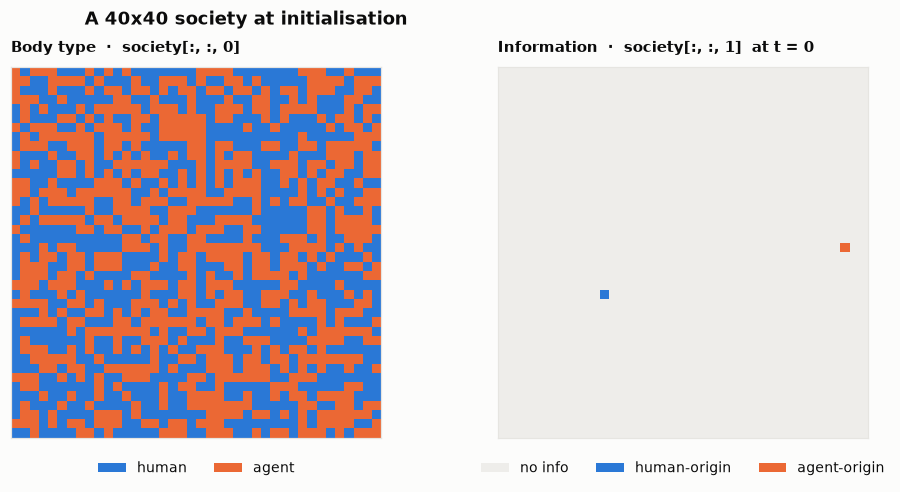

population        1600
agents            800
seeded bodies     2  -> ['human-origin', 'agent-origin']

example cells (the brief's [kind, X] schema):
  society[19, 37] = [1, 2]   (agent holding agent-origin)
  society[24, 11] = [0, 1]   (human holding human-origin)


In [4]:
demo_p = replace(ONE_SHOT, n=40, seed=7)
rng = np.random.default_rng(demo_p.seed)
demo = seed_information(make_society(demo_p, rng), demo_p, rng)
kind, info = views(demo)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
show_lattice(axes[0], kind, KIND_CMAP, vmax=1, title="Body type  ·  society[:, :, 0]")
show_lattice(axes[1], info, INFO_CMAP, vmax=2, title="Information  ·  society[:, :, 1]  at t = 0")
axes[0].legend(handles=[Patch(facecolor=C_HUMAN, label="human"), Patch(facecolor=C_AGENT, label="agent")],
               loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False, fontsize=9)
axes[1].legend(handles=[Patch(facecolor=C_NONE, label="no info"),
                        Patch(facecolor=C_HUMAN, label="human-origin"),
                        Patch(facecolor=C_AGENT, label="agent-origin")],
               loc="upper center", bbox_to_anchor=(0.5, -0.03), ncol=3, frameon=False, fontsize=9)
fig.suptitle("A 40x40 society at initialisation", x=0.125, ha="left", fontsize=12, weight="bold")
fig.tight_layout(); plt.show()

print(f"population        {demo_p.n**2}")
print(f"agents            {np.count_nonzero(kind == AGENT)}")
print(f"seeded bodies     {np.count_nonzero(info != NONE)}  "
      f"-> {[INFO_NAME[v] for v in np.unique(info[info != NONE])]}")
print("\nexample cells (the brief's [kind, X] schema):")
r, c = np.nonzero(info != NONE)
for i in range(len(r)):
    print(f"  society[{r[i]:2d}, {c[i]:2d}] = {[int(v) for v in demo[r[i], c[i]]]}   "
          f"({KIND_NAME[demo[r[i], c[i], 0]]} holding {INFO_NAME[demo[r[i], c[i], 1]]})")

---
# 3. Who is active on tick `t`

Speed enters the model here and nowhere else. An agent with `period = 1` is active every
tick; a human with `period = 3` is active on one tick in three. The random `phase` spreads
humans evenly across the three-tick cycle.

In [5]:
def active_mask(t: int, period, phase):
    """Boolean (n, n) mask: which bodies act on tick t."""
    return ((t + phase) % period) == 0

### Check it

Two things to confirm: agents are active every tick, humans on a third of ticks, and the
active humans are a *different* third each tick rather than all of them at once.

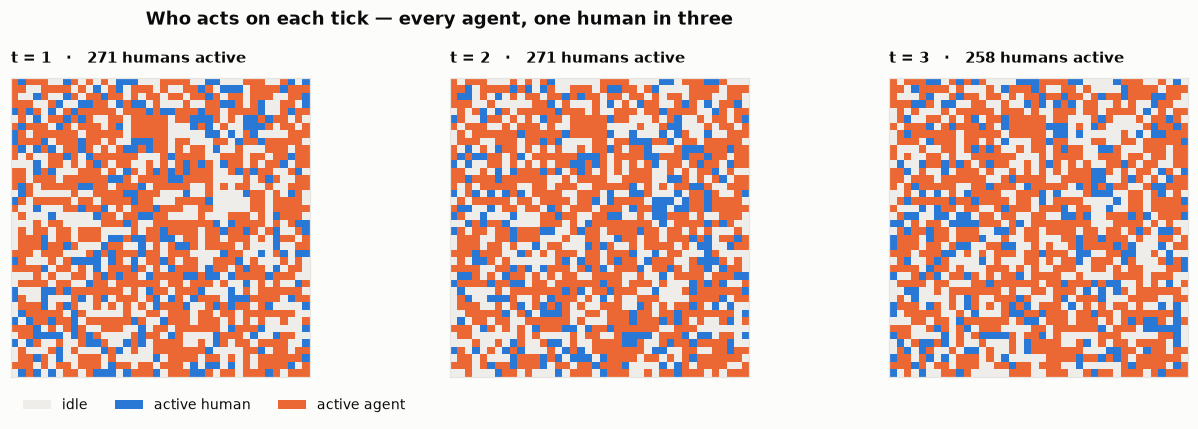

agent activity rate  1.000   (expected 1.000)
human activity rate  0.333   (expected 0.333)
speed ratio          3.0x


In [6]:
period, phase = make_clocks(demo, demo_p, rng)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.9))
for ax, t in zip(axes, (1, 2, 3)):
    act = active_mask(t, period, phase)
    plane = np.where(act, kind.astype(int) + 1, 0)     # 0 idle, 1 active human, 2 active agent
    show_lattice(ax, plane, ListedColormap([C_NONE, C_HUMAN, C_AGENT]), vmax=2,
                 title=f"t = {t}   ·   {np.count_nonzero(act & (kind == HUMAN))} humans active")
axes[0].legend(handles=[Patch(facecolor=C_NONE, label="idle"),
                        Patch(facecolor=C_HUMAN, label="active human"),
                        Patch(facecolor=C_AGENT, label="active agent")],
               loc="upper left", bbox_to_anchor=(0, -0.03), ncol=3, frameon=False, fontsize=9)
fig.suptitle("Who acts on each tick — every agent, one human in three",
             x=0.125, ha="left", fontsize=12, weight="bold")
fig.tight_layout(); plt.show()

rates = np.mean([active_mask(t, period, phase) for t in range(1, 61)], axis=0)
print(f"agent activity rate  {rates[kind == AGENT].mean():.3f}   (expected {1/demo_p.agent_period:.3f})")
print(f"human activity rate  {rates[kind == HUMAN].mean():.3f}   (expected {1/demo_p.human_period:.3f})")
print(f"speed ratio          {demo_p.speed_ratio:.1f}x")

---
# 4. Whom to consult — the intervention

An active body consults exactly one of its four neighbours. The lattice is a torus
(`np.roll` wraps the edges), so no body is disadvantaged by sitting near a border.

Choice weights are `1` for every neighbour, except that an **agent** consulting a
**human** gets weight `exp(beta)`. So `beta = 0` is uniform choice and larger `beta`
means agents seek humans out. Selection uses the Gumbel-max trick, which samples from a
weighted categorical distribution across the whole lattice in one vectorised step.

**This function is the entire claim-3 intervention.** Nothing else in the model changes
when the intervention is applied — it is a parameter, not a rewrite.

In [7]:
def neighbour_stack(plane):
    """Stack the four toroidal neighbours of every cell: shape (4, n, n)."""
    return np.stack([np.roll(plane,  1, axis=0), np.roll(plane, -1, axis=0),
                     np.roll(plane,  1, axis=1), np.roll(plane, -1, axis=1)])


def consult_log_weights(kind, beta: float):
    """Log-weight of each of the 4 neighbours as a consultation target. Constant over time."""
    nb_kind = neighbour_stack(kind)
    return np.where((kind == AGENT)[None] & (nb_kind == HUMAN), beta, 0.0)


def choose_neighbour(log_w, rng):
    """Gumbel-max sampling: index in 0..3 of the neighbour each body consults this tick."""
    return np.argmax(log_w + rng.gumbel(size=log_w.shape), axis=0)


def gather(stack, choice):
    """Pick out the chosen neighbour's value from a (4, n, n) stack."""
    return np.take_along_axis(stack, choice[None], axis=0)[0]

### Check it

Sanity check on the knob: with `beta = 0` an agent should consult humans about half the
time (they are half the population); as `beta` grows that fraction should approach 1.

In [8]:
nb_kind = neighbour_stack(kind)
print("beta   P(consults a human | agent is consulting)")
for b in (0.0, 0.5, 1.0, 2.0, 4.0):
    log_w = consult_log_weights(kind, b)
    picks = [gather(nb_kind, choose_neighbour(log_w, rng))[kind == AGENT] == HUMAN for _ in range(40)]
    print(f"{b:4.1f}   {np.mean(picks):.3f}")

beta   P(consults a human | agent is consulting)
 0.0   0.487
 0.5   0.582
 1.0   0.667
 2.0   0.801
 4.0   0.911


---
# 5. One tick of the simulation

The whole mechanism, in one function. Reading it top to bottom is reading the four rules
from the model summary.

Two details worth noting. The neighbour's information is read from `neighbour_stack(info)`
*before* anything is written, so the update is simultaneous rather than sequential. And
because information is pulled, each body writes only to its own cell — no two bodies ever
contend for the same slot.

Step 5 is the second of the two interventions, added in section 11: where `beta` changes
*whom* an agent consults, `gamma` changes *how readily it believes what it hears* — a
change to the individual agent's policy rather than to the interaction graph. It is
inert at `gamma = 0`.

The returned `contact` mask (who successfully consulted whom) is what claim 1 is measured
from. Note it counts a consultation that got a *response*, whether or not any information
changed hands — clustering is about who talks to whom, not about what was said.

In [9]:
def step(t, society, period, phase, nb_kind, log_w, p: Params, rng):
    """Advance the society by one tick, in place. Returns (contact mask, partner kinds)."""
    kind, info = views(society)

    # 1. act
    act = active_mask(t, period, phase)

    # 2. consult one neighbour
    choice = choose_neighbour(log_w, rng)
    partner_kind = gather(nb_kind, choice)
    partner_info = gather(neighbour_stack(info), choice)
    partner_act  = gather(neighbour_stack(act), choice)

    # 3. the neighbour responds only if it is active too (unless the gate is switched off)
    responds = partner_act if p.gate_acceptance else np.ones_like(act)
    contact = act & responds

    # 4. adopt the neighbour's information
    receptive = np.ones_like(act) if p.overwrite else (info == NONE)
    if p.human_retention > 0:
        holding_out = (kind == HUMAN) & (info != NONE) & (rng.random(act.shape) < p.human_retention)
        receptive = receptive & ~holding_out
    adopt = contact & (partner_info != NONE) & receptive

    # 5. an agent may hold AI-sourced information to a higher bar than human-sourced
    #    (the agent-policy intervention; gamma = 0 leaves every threshold equal)
    if p.gamma > 0:
        ai_flavoured = (partner_kind == AGENT) if p.gamma_on == "source" else (partner_info == AGENT_INFO)
        harder = (kind == AGENT) & ai_flavoured
        adopt = adopt & ~(harder & (rng.random(act.shape) > np.exp(-p.gamma)))

    info[adopt] = partner_info[adopt]

    # 6. optionally originate fresh information, tagged with the originator's own kind
    if p.p_new > 0:
        born = act & (rng.random(act.shape) < p.p_new)
        info[born] = np.where(kind[born] == AGENT, AGENT_INFO, HUMAN_INFO)

    return contact, partner_kind


def contact_census(contact, kind, partner_kind):
    """2x2 count of successful consultations: rows = initiator kind, cols = partner kind."""
    c = np.zeros((2, 2), dtype=np.int64)
    for a in (HUMAN, AGENT):
        for b in (HUMAN, AGENT):
            c[a, b] = np.count_nonzero(contact & (kind == a) & (partner_kind == b))
    return c


def state_counts(kind, info):
    """The 2x2 of body type against information origin, flattened."""
    return np.array([
        np.count_nonzero((kind == HUMAN) & (info == HUMAN_INFO)),   # 0: human body, human info
        np.count_nonzero((kind == HUMAN) & (info == AGENT_INFO)),   # 1: human body, agent info
        np.count_nonzero((kind == AGENT) & (info == HUMAN_INFO)),   # 2: agent body, human info
        np.count_nonzero((kind == AGENT) & (info == AGENT_INFO)),   # 3: agent body, agent info
    ])

STATE_LABELS = ["human body / human-origin", "human body / agent-origin",
                "agent body / human-origin", "agent body / agent-origin"]

---
# 6. Running a simulation

`run` wires the pieces together and records history. It returns a plain dict so results
are easy to poke at.

- `counts` — `(T, 4)` array, the body-type × origin table on every tick
- `census` — the `2×2` contact table accumulated over the whole run
- `frames` — copies of the information plane at the requested ticks, for the figures

In [10]:
def run(p: Params, snapshots=()):
    """Run one simulation. Returns a dict of recorded history."""
    rng = np.random.default_rng(p.seed)
    society = seed_information(make_society(p, rng), p, rng)
    kind, info = views(society)
    period, phase = make_clocks(society, p, rng)

    nb_kind = neighbour_stack(kind)                    # kinds never change
    log_w = consult_log_weights(kind, p.beta)          # so weights are constant too

    census = np.zeros((2, 2), dtype=np.int64)
    counts = np.empty((p.T, 4), dtype=np.int64)
    frames = {0: info.copy()} if 0 in snapshots else {}

    for t in range(1, p.T + 1):
        contact, partner_kind = step(t, society, period, phase, nb_kind, log_w, p, rng)
        census += contact_census(contact, kind, partner_kind)
        counts[t - 1] = state_counts(kind, info)
        if t in snapshots:
            frames[t] = info.copy()

    return {"params": p, "society": society, "counts": counts,
            "census": census, "frames": frames, "population": p.n * p.n}


# --- derived quantities --------------------------------------------------------
def origin_shares(res):
    """(T, 2) fractions of the whole population holding human-origin / agent-origin info."""
    c = res["counts"]
    return np.stack([c[:, 0] + c[:, 2], c[:, 1] + c[:, 3]], axis=1) / res["population"]

def agent_partner_rate(res):
    """Claim 1: of the consultations an agent initiated, what fraction reached another agent."""
    row = res["census"][AGENT]
    return row[AGENT] / row.sum()

def homophily_index(res):
    """Claim 1, normalised: 0 = type-blind mixing, 1 = agents only ever reach agents."""
    observed = agent_partner_rate(res)
    expected = res["params"].frac_agents      # share of agents among neighbours
    return (observed - expected) / (1 - expected)

def final_shares(res, tail=None):
    """Mean origin shares over the last `tail` ticks (default: the run's second half)."""
    tail = tail or res["params"].T // 2
    return origin_shares(res)[-tail:].mean(axis=0)

def dominance_ratio(res, tail=None):
    """Claim 2/3: agent-origin share divided by human-origin share. 1.0 is parity."""
    human, agent = final_shares(res, tail)
    return agent / max(human, 1e-12)

---
# 7. Watching the diffusion

Now the picture the model exists to produce. One-shot regime: a single human and a single
agent are seeded at `t = 0`, and the two origins spread outward and compete for territory.
Each body keeps the first information that reaches it.

Watch for the shape of the two fronts and for how they meet.

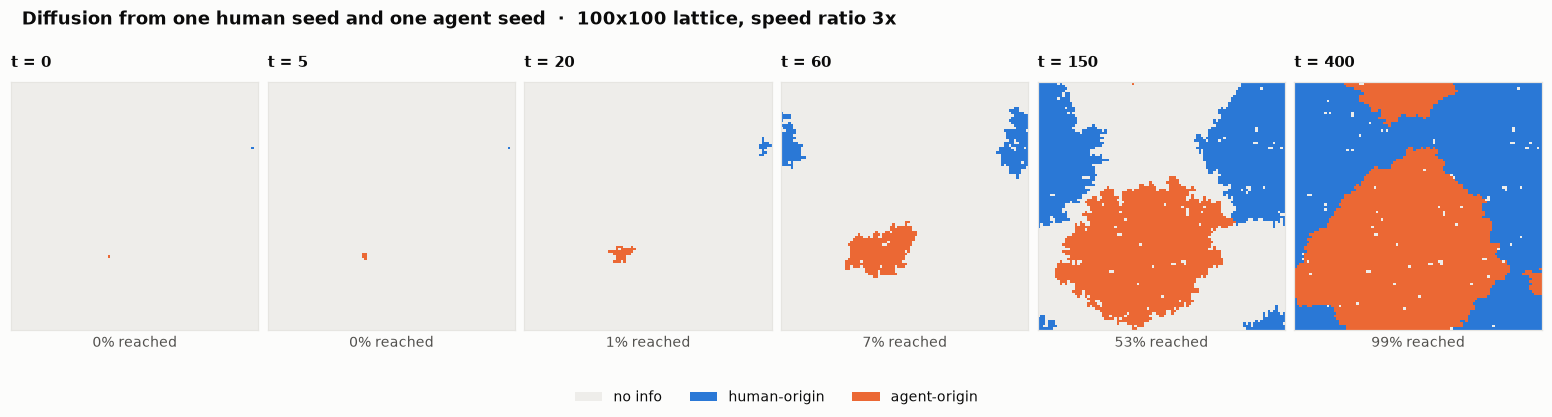

In [11]:
SNAPS = (0, 5, 20, 60, 150, 400)
demo_run = run(replace(ONE_SHOT, n=100, T=400, seed=3), snapshots=SNAPS)

fig, axes = plt.subplots(1, len(SNAPS), figsize=(14, 3.7), constrained_layout=True)
for ax, t in zip(axes, SNAPS):
    frame = demo_run["frames"][t]
    reached = np.count_nonzero(frame != NONE) / demo_run["population"]
    show_lattice(ax, frame, INFO_CMAP, vmax=2, title=f"t = {t}")
    ax.set_xlabel(f"{reached:.0%} reached", fontsize=9, color=MUTED)
fig.legend(handles=INFO_LEGEND, loc="outside lower center", ncol=3, frameon=False, fontsize=9)
fig.suptitle("Diffusion from one human seed and one agent seed  ·  100x100 lattice, speed ratio 3x",
             x=0.01, ha="left", fontsize=12, weight="bold")
plt.show()

The same run as a time series. This is the metric the brief was missing: **the fraction of
the population holding information from each origin, over time.**

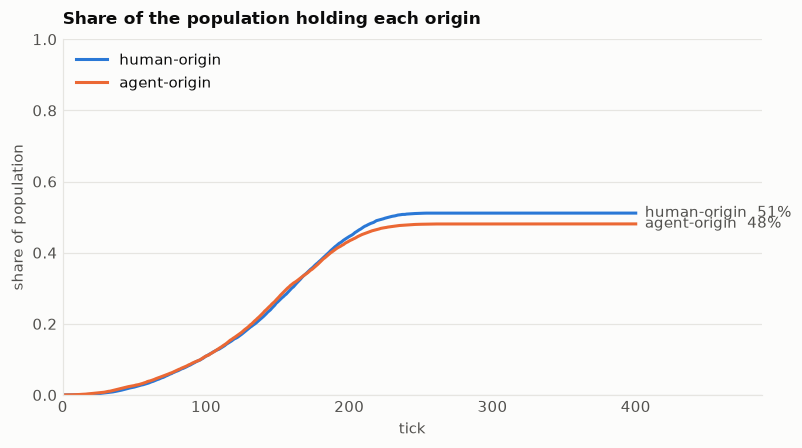

In [12]:
shares = origin_shares(demo_run)
ticks = np.arange(1, len(shares) + 1)

fig, ax = plt.subplots(figsize=(8.2, 4.2))
for col, colour, label in ((0, C_HUMAN, "human-origin"), (1, C_AGENT, "agent-origin")):
    ax.plot(ticks, shares[:, col], color=colour, linewidth=2, label=label)
    ax.annotate(f"{label}  {shares[-1, col]:.0%}", xy=(ticks[-1], shares[-1, col]),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, color=MUTED)
tidy(ax, title="Share of the population holding each origin",
     xlabel="tick", ylabel="share of population")
ax.set_xlim(0, ticks[-1] * 1.22); ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper left")
plt.show()

---
# 8. Claim 1 — fast agents cluster

**Prediction.** Because a consultation succeeds only when *both* parties are active, the
rate of contact between two body types scales as the product of their activity rates.
With agents active every tick and humans one tick in three:

| | agent → agent | agent → human | human → human |
|---|---|---|---|
| relative contact rate | 1 | 1/3 | 1/9 |

So of the consultations an agent initiates, agent partners should be over-represented by a
factor of 3 — giving `0.5 / (0.5 + 0.5/3) = 0.75` against a 50% baseline, with **no
homophily assumed anywhere in the model**. Only speed differs.

**Control.** Setting `gate_acceptance = False` lets neighbours respond whether or not they
are active. That removes the product structure and should collapse the effect to the
baseline. If the control does *not* collapse, the clustering came from somewhere else and
the mechanism is wrong.

In [13]:
PERIODS = [1, 2, 3, 5, 8]
REPS = 3
claim1 = {"gated": [], "ungated": []}

for hp in PERIODS:
    for gate, key in ((True, "gated"), (False, "ungated")):
        base = replace(ONE_SHOT, n=60, T=300, human_period=hp, gate_acceptance=gate)
        claim1[key].append(np.mean([agent_partner_rate(run(replace(base, seed=s))) for s in range(REPS)]))

claim1 = {k: np.array(v) for k, v in claim1.items()}
baseline = ONE_SHOT.frac_agents

print(" speed ratio | gated (mutual availability) | ungated control | predicted")
for i, hp in enumerate(PERIODS):
    pred = 1 / (1 + 1 / hp)          # (1) / (1 + 1/hp) with equal type frequencies
    print(f"     {hp}x      |            {claim1['gated'][i]:.3f}            "
          f"|      {claim1['ungated'][i]:.3f}      |   {pred:.3f}")

 speed ratio | gated (mutual availability) | ungated control | predicted
     1x      |            0.494            |      0.494      |   0.500
     2x      |            0.661            |      0.494      |   0.667
     3x      |            0.745            |      0.494      |   0.750
     5x      |            0.830            |      0.494      |   0.833
     8x      |            0.886            |      0.494      |   0.889


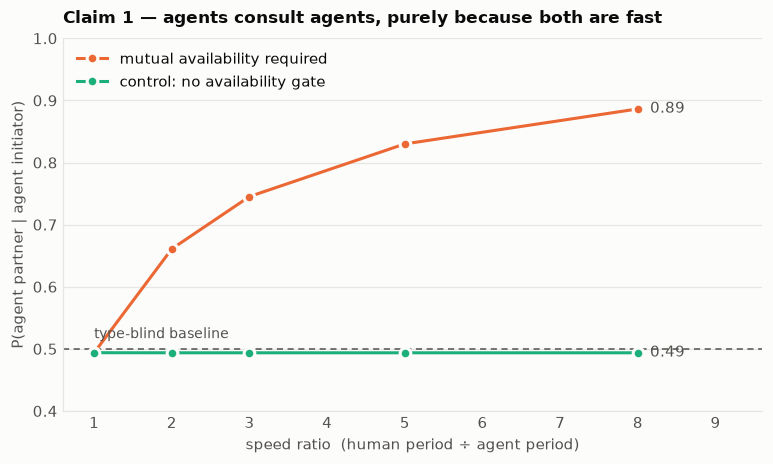

at the default 3x speed ratio: 0.745 vs baseline 0.50 -> homophily index 0.49
control at the same ratio:     0.494  (effect gone, as it should be)


In [14]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.axhline(baseline, color=MUTED, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("type-blind baseline", xy=(PERIODS[0], baseline), xytext=(0, 7),
            textcoords="offset points", fontsize=9, color=MUTED)
for key, colour, label in (("gated", C_AGENT, "mutual availability required"),
                           ("ungated", C_ALT, "control: no availability gate")):
    ax.plot(PERIODS, claim1[key], color=colour, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label)
    ax.annotate(f"{claim1[key][-1]:.2f}", xy=(PERIODS[-1], claim1[key][-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=MUTED)
tidy(ax, title="Claim 1 — agents consult agents, purely because both are fast",
     xlabel="speed ratio  (human period ÷ agent period)",
     ylabel="P(agent partner | agent initiator)")
ax.set_xlim(0.6, 9.6); ax.set_ylim(0.4, 1.0)
ax.legend(frameon=False, loc="upper left")
plt.show()

i3 = PERIODS.index(3)
print(f"at the default 3x speed ratio: {claim1['gated'][i3]:.3f} vs baseline {baseline:.2f} "
      f"-> homophily index {(claim1['gated'][i3] - baseline) / (1 - baseline):.2f}")
print(f"control at the same ratio:     {claim1['ungated'][i3]:.3f}  (effect gone, as it should be)")

---
# 9. Claim 2 — does fast information dominate?

This is where the model says something the brief did not anticipate, so it is worth
running the claim in **both** regimes and comparing.

### 9a. One-shot seeding — the claim fails

Seed one human and one agent, let the origins race. Intuition says the agent-origin
information should win easily. It does not, and the reason is instructive: **once
human-origin information escapes into its first agent, it is carried by the fast network
exactly as well as agent-origin information is.** The fingerprint travels with the
information, so after the first hop the two origins are mechanically identical. The only
asymmetry left is a head start of a few ticks while the human seed waits for an agent to
consult it — negligible over a long run.

A one-shot race therefore measures *seed placement*, not speed.

In [15]:
REPS_2A = 12
runs_2a = [run(replace(ONE_SHOT, n=80, T=500, seed=s)) for s in range(REPS_2A)]
shares_2a = np.stack([origin_shares(r) for r in runs_2a])          # (reps, T, 2)
final_2a = shares_2a[:, -1, :]

print(f"one-shot regime, {REPS_2A} replicates, final shares")
print(f"  human-origin  {final_2a[:, 0].mean():.3f}  (sd {final_2a[:, 0].std():.3f})")
print(f"  agent-origin  {final_2a[:, 1].mean():.3f}  (sd {final_2a[:, 1].std():.3f})")
print(f"  dominance ratio {final_2a[:, 1].mean() / final_2a[:, 0].mean():.2f}   "
      f"-> parity, not domination")

one-shot regime, 12 replicates, final shares
  human-origin  0.464  (sd 0.058)
  agent-origin  0.530  (sd 0.058)
  dominance ratio 1.14   -> parity, not domination


### 9b. Ongoing origination — the claim holds

The realistic setting is not one message but a continuous stream: bodies keep producing
information, and new information displaces old. Set `p_new > 0` and `overwrite = True`.
Now agents originate three times as often as humans *because* they act three times as
often, and the population reaches a steady state in which the origins hold a stable share
each.

This is the regime where "drowns out" has a meaning that does not depend on when you stop
looking.

In [16]:
REPS_2B = 6
runs_2b = [run(replace(ONGOING, seed=s)) for s in range(REPS_2B)]
shares_2b = np.stack([origin_shares(r) for r in runs_2b])
final_2b = np.stack([final_shares(r) for r in runs_2b])

print(f"ongoing regime, {REPS_2B} replicates, steady-state shares (mean of the second half of the run)")
print(f"  human-origin  {final_2b[:, 0].mean():.3f}  (sd {final_2b[:, 0].std():.3f})")
print(f"  agent-origin  {final_2b[:, 1].mean():.3f}  (sd {final_2b[:, 1].std():.3f})")
print(f"  dominance ratio {final_2b[:, 1].mean() / final_2b[:, 0].mean():.2f}")

ongoing regime, 6 replicates, steady-state shares (mean of the second half of the run)
  human-origin  0.219  (sd 0.022)
  agent-origin  0.777  (sd 0.022)
  dominance ratio 3.55


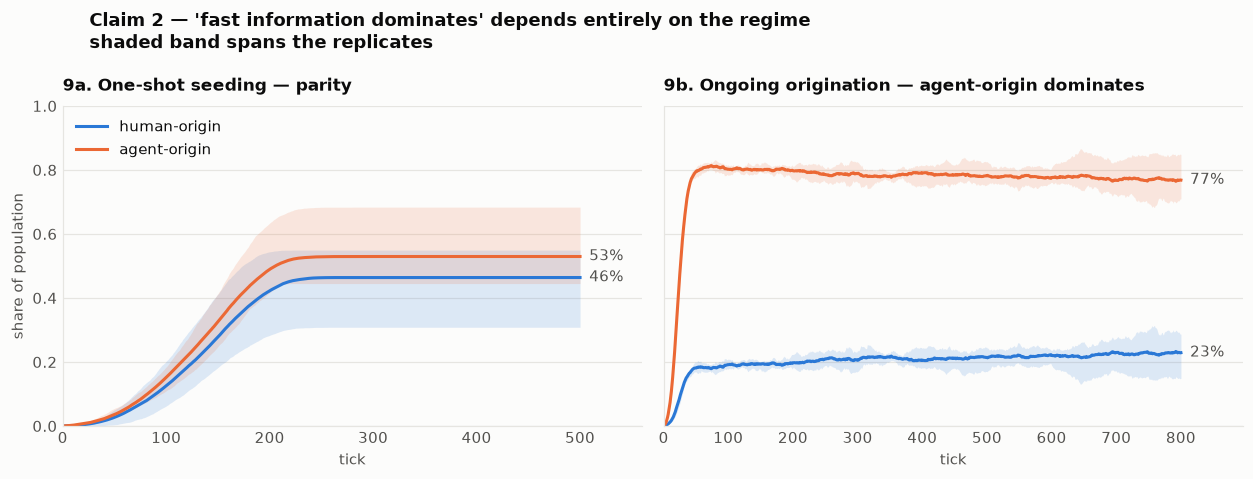

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
panels = [(axes[0], shares_2a, "9a. One-shot seeding — parity"),
          (axes[1], shares_2b, "9b. Ongoing origination — agent-origin dominates")]

for ax, data, title in panels:
    ticks = np.arange(1, data.shape[1] + 1)
    for col, colour, label in ((0, C_HUMAN, "human-origin"), (1, C_AGENT, "agent-origin")):
        mean = data[:, :, col].mean(axis=0)
        ax.fill_between(ticks, data[:, :, col].min(axis=0), data[:, :, col].max(axis=0),
                        color=colour, alpha=0.15, linewidth=0)
        ax.plot(ticks, mean, color=colour, linewidth=2, label=label)
        ax.annotate(f"{mean[-1]:.0%}", xy=(ticks[-1], mean[-1]), xytext=(6, 0),
                    textcoords="offset points", va="center", fontsize=9.5, color=MUTED)
    tidy(ax, title=title, xlabel="tick")
    ax.set_xlim(0, ticks[-1] * 1.12); ax.set_ylim(0, 1)

axes[0].set_ylabel("share of population")
axes[0].legend(frameon=False, loc="upper left")
fig.suptitle("Claim 2 — 'fast information dominates' depends entirely on the regime\n"
             "shaded band spans the replicates",
             x=0.075, ha="left", fontsize=12, weight="bold")
fig.tight_layout(); plt.show()

### What the steady state looks like on the lattice

In the ongoing regime the map stops being two spreading fronts and becomes a churning
mosaic. The orange majority *is* claim 2.

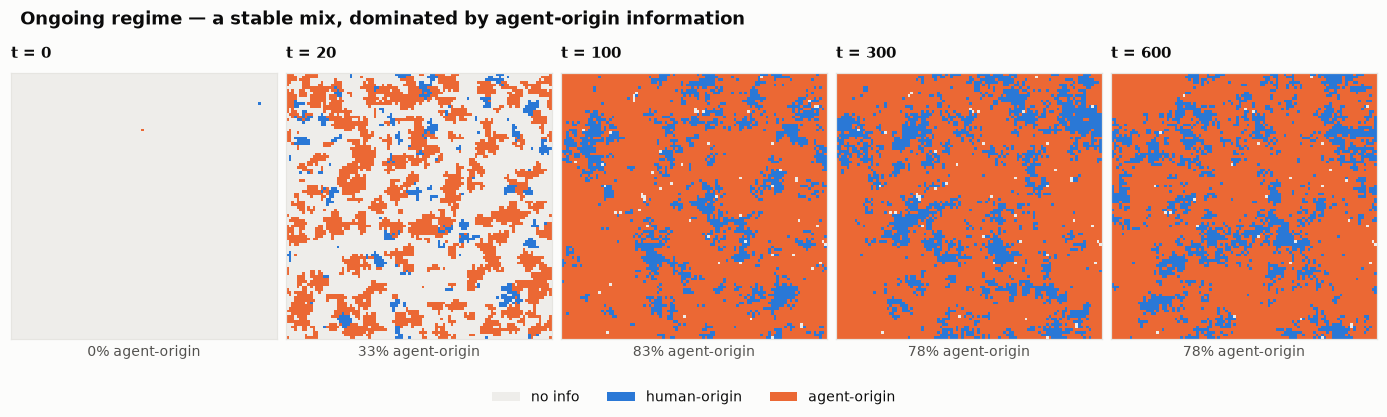

In [18]:
mosaic = run(replace(ONGOING, n=100, T=600, seed=2), snapshots=(0, 20, 100, 300, 600))
fig, axes = plt.subplots(1, 5, figsize=(12.5, 3.7), constrained_layout=True)
for ax, t in zip(axes, sorted(mosaic["frames"])):
    frame = mosaic["frames"][t]
    ag = np.count_nonzero(frame == AGENT_INFO) / mosaic["population"]
    show_lattice(ax, frame, INFO_CMAP, vmax=2, title=f"t = {t}")
    ax.set_xlabel(f"{ag:.0%} agent-origin", fontsize=9, color=MUTED)
fig.legend(handles=INFO_LEGEND, loc="outside lower center", ncol=3, frameon=False, fontsize=9)
fig.suptitle("Ongoing regime — a stable mix, dominated by agent-origin information",
             x=0.01, ha="left", fontsize=12, weight="bold")
plt.show()

---
# 10. Claim 3, lever one — change *whom* agents consult

The lever is `beta`: encourage agents to consult humans. Nothing else about the agents
changes — not their speed, not their policy. We sweep `beta` in the ongoing regime and
watch the dominance ratio.

We run **two arms**, because the first one alone reveals a limitation worth knowing about:

- `human_retention = 0` — humans adopt whatever they are told, like agents do.
- `human_retention = 0.9` — humans mostly hold on to what they already believe.

The second arm exists because of a problem the first one exposes: if humans have
themselves been saturated with agent-origin information, then telling agents to "go ask a
human" mostly returns agent-origin information anyway. Consulting a drowned population
does not undo the drowning. Human retention keeps humans a genuine reservoir of
human-origin information, which is what the intervention needs in order to have something
to draw on.

**Reference lines.** `1.0` is parity. `3.0` is the ratio of *production* rates — agents
originate information three times as often as humans, so a purely fair transmission
network would still land there. Getting below 3.0 means consultation is doing real work.

In [19]:
BETAS = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
RETENTIONS = [0.0, 0.9]
REPS_3 = 8          # this sweep is the slowest cell in the notebook — about a minute


def agent_reach(res):
    """Share of AGENT bodies holding human-origin information: the direct claim-3 observable."""
    tail = res["params"].T // 2
    return res["counts"][-tail:, 2].mean() / (res["population"] * res["params"].frac_agents)


claim3 = {}
for ret in RETENTIONS:
    arm = {"ratio": [], "ratio_sd": [], "reach": [], "reach_sd": []}
    for b in BETAS:
        base = replace(ONGOING, beta=b, human_retention=ret)
        rs = [run(replace(base, seed=s)) for s in range(REPS_3)]
        ratios = [dominance_ratio(r) for r in rs]
        reach  = [agent_reach(r) for r in rs]
        arm["ratio"].append(np.mean(ratios));  arm["ratio_sd"].append(np.std(ratios))
        arm["reach"].append(np.mean(reach));   arm["reach_sd"].append(np.std(reach))
    claim3[ret] = {k: np.array(v) for k, v in arm.items()}

print(f"{REPS_3} replicates per point, mean +/- sd")
print(" beta |   retention 0.0            |   retention 0.9")
print("      |  ratio        agents w/ hum |  ratio        agents w/ hum")
for i, b in enumerate(BETAS):
    a, c = claim3[0.0], claim3[0.9]
    print(f" {b:4.1f} | {a['ratio'][i]:5.2f}+/-{a['ratio_sd'][i]:.2f}   {a['reach'][i]:.3f}      "
          f"| {c['ratio'][i]:5.2f}+/-{c['ratio_sd'][i]:.2f}   {c['reach'][i]:.3f}")

8 replicates per point, mean +/- sd
 beta |   retention 0.0            |   retention 0.9
      |  ratio        agents w/ hum |  ratio        agents w/ hum
  0.0 |  3.53+/-0.47   0.216      |  1.15+/-0.17   0.457
  0.5 |  2.68+/-0.32   0.267      |  1.03+/-0.14   0.485
  1.0 |  2.51+/-0.48   0.283      |  0.97+/-0.16   0.501
  2.0 |  1.93+/-0.20   0.336      |  0.85+/-0.09   0.532
  3.0 |  1.86+/-0.29   0.348      |  0.83+/-0.09   0.539
  5.0 |  1.93+/-0.25   0.335      |  0.81+/-0.09   0.545


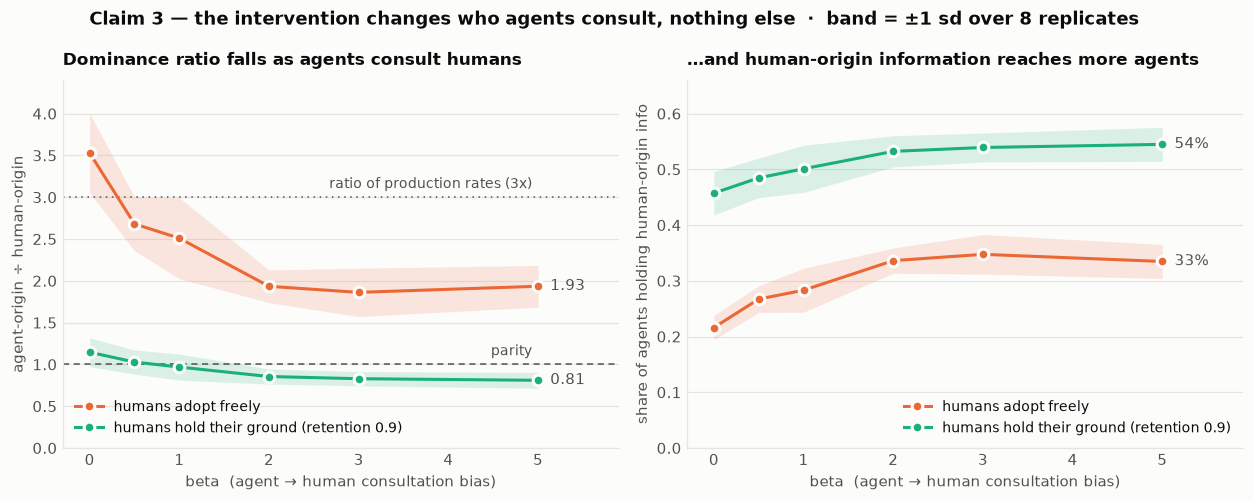

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
arms = ((0.0, C_AGENT, "humans adopt freely"), (0.9, C_ALT, "humans hold their ground (retention 0.9)"))

ax = axes[0]
ax.axhline(1.0, color=MUTED, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("parity", xy=(BETAS[-1], 1.0), xytext=(-4, 6), textcoords="offset points",
            ha="right", fontsize=9, color=MUTED)
ax.axhline(3.0, color=MUTED, linestyle=(0, (1, 3)), linewidth=1)
ax.annotate("ratio of production rates (3x)", xy=(BETAS[-1], 3.0), xytext=(-4, 6),
            textcoords="offset points", ha="right", fontsize=9, color=MUTED)
for ret, colour, label in arms:
    y, sd = claim3[ret]["ratio"], claim3[ret]["ratio_sd"]
    ax.fill_between(BETAS, y - sd, y + sd, color=colour, alpha=0.15, linewidth=0)
    ax.plot(BETAS, y, color=colour, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label)
    ax.annotate(f"{y[-1]:.2f}", xy=(BETAS[-1], y[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=MUTED)
tidy(ax, title="Dominance ratio falls as agents consult humans",
     xlabel="beta  (agent → human consultation bias)", ylabel="agent-origin ÷ human-origin")
ax.set_xlim(-0.3, 5.9); ax.set_ylim(0, 4.4)
ax.legend(frameon=False, loc="lower left", fontsize=9)

ax = axes[1]
for ret, colour, label in arms:
    y, sd = claim3[ret]["reach"], claim3[ret]["reach_sd"]
    ax.fill_between(BETAS, y - sd, y + sd, color=colour, alpha=0.15, linewidth=0)
    ax.plot(BETAS, y, color=colour, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label)
    ax.annotate(f"{y[-1]:.0%}", xy=(BETAS[-1], y[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=MUTED)
tidy(ax, title="…and human-origin information reaches more agents",
     xlabel="beta  (agent → human consultation bias)",
     ylabel="share of agents holding human-origin info")
ax.set_xlim(-0.3, 5.9); ax.set_ylim(0, 0.66)
ax.legend(frameon=False, loc="lower right", fontsize=9)

fig.suptitle("Claim 3 — the intervention changes who agents consult, nothing else"
             f"  ·  band = ±1 sd over {REPS_3} replicates",
             x=0.075, ha="left", fontsize=12, weight="bold")
fig.tight_layout(); plt.show()

---
# 11. Claim 3, lever two — change *how readily agents believe what they hear*

`beta` is a change to the interaction graph: it rewires who talks to whom, and leaves each
agent's policy untouched. The alternative is to intervene inside the agent — lower its
threshold for accepting information that came from a human, relative to information that
came from another AI agent. That is a change to `P(action | state)` itself.

`gamma` is that threshold, expressed as a difficulty: an agent accepts human-flavoured
information as before, and AI-flavoured information only with probability `exp(-gamma)`.
`gamma = 0` is no preference; large `gamma` means an agent almost never takes an AI's word
for anything.

**"Came from a human" has two readings, and the difference turns out to matter more than
the parameter does.** `gamma_on` picks between them:

- **`"source"`** — keyed on *who relayed it*, the neighbour the agent just consulted. This
  is what an agent can actually observe locally: it knows who it is talking to and nothing
  about where the content originally came from.
- **`"origin"`** — keyed on the information's own provenance tag `X`. This requires the
  content to carry a durable, trustworthy marker of where it started, which is a real
  infrastructure assumption, not a free one.

We sweep both. Note the two are plotted on **different x-scales**, because they turn out to
operate at wildly different magnitudes — that difference is the result.

In [21]:
GAMMAS_SOURCE = [0.0, 0.5, 1.0, 2.0, 3.0, 5.0]
GAMMAS_ORIGIN = [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.40]


def sweep(values, key, **fixed):
    """Run REPS_3 replicates at each value of one parameter; return mean and sd of the ratio."""
    mean, sd = [], []
    for v in values:
        base = replace(ONGOING, **{key: v}, **fixed)
        ratios = [dominance_ratio(run(replace(base, seed=s))) for s in range(REPS_3)]
        mean.append(np.mean(ratios)); sd.append(np.std(ratios))
    return np.array(mean), np.array(sd)


g_source, g_source_sd = sweep(GAMMAS_SOURCE, "gamma", gamma_on="source")
g_origin, g_origin_sd = sweep(GAMMAS_ORIGIN, "gamma", gamma_on="origin")

print(f"{REPS_3} replicates per point.  Dominance ratio (1.00 = parity)\n")
print("keyed on the SOURCE that relayed it        keyed on the information's ORIGIN tag")
for i in range(max(len(GAMMAS_SOURCE), len(GAMMAS_ORIGIN))):
    left = (f"  gamma {GAMMAS_SOURCE[i]:4.2f} -> {g_source[i]:5.2f} +/- {g_source_sd[i]:.2f}"
            if i < len(GAMMAS_SOURCE) else " " * 32)
    right = (f"    gamma {GAMMAS_ORIGIN[i]:4.2f} -> {g_origin[i]:5.2f} +/- {g_origin_sd[i]:.2f}"
             if i < len(GAMMAS_ORIGIN) else "")
    print(f"{left:<42}{right}")

8 replicates per point.  Dominance ratio (1.00 = parity)

keyed on the SOURCE that relayed it        keyed on the information's ORIGIN tag
  gamma 0.00 ->  3.53 +/- 0.47                gamma 0.00 ->  3.53 +/- 0.47
  gamma 0.50 ->  3.56 +/- 0.44                gamma 0.01 ->  1.95 +/- 0.45
  gamma 1.00 ->  3.42 +/- 0.59                gamma 0.02 ->  1.13 +/- 0.26
  gamma 2.00 ->  3.33 +/- 0.37                gamma 0.05 ->  0.25 +/- 0.03
  gamma 3.00 ->  3.00 +/- 0.48                gamma 0.10 ->  0.08 +/- 0.00
  gamma 5.00 ->  2.79 +/- 0.20                gamma 0.20 ->  0.04 +/- 0.00
                                              gamma 0.40 ->  0.02 +/- 0.00


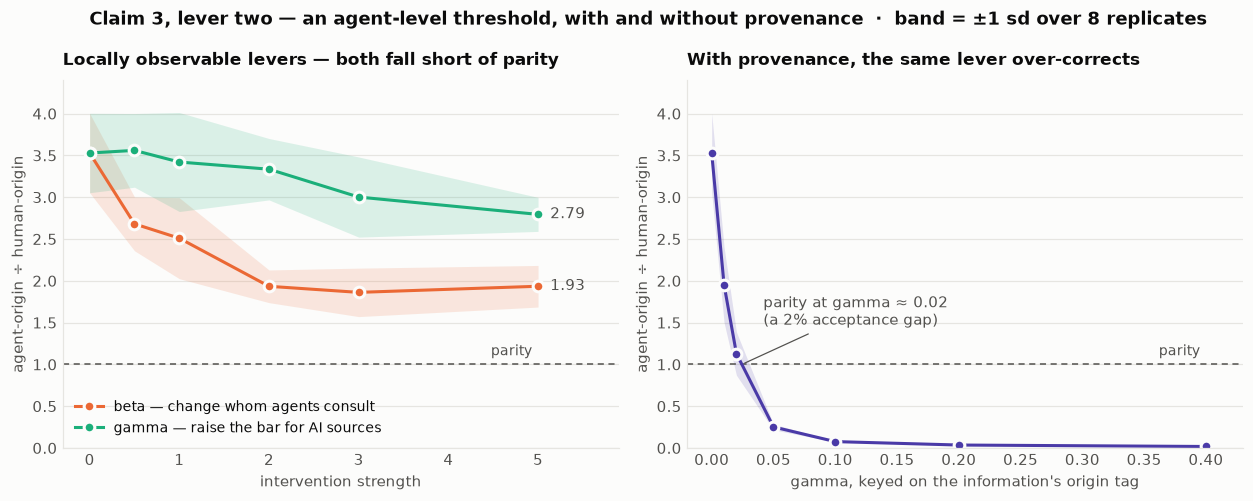

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
ax.axhline(1.0, color=MUTED, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("parity", xy=(5.0, 1.0), xytext=(-4, 6), textcoords="offset points",
            ha="right", fontsize=9, color=MUTED)
series = ((BETAS, claim3[0.0]["ratio"], claim3[0.0]["ratio_sd"], C_AGENT,
           "beta — change whom agents consult"),
          (GAMMAS_SOURCE, g_source, g_source_sd, C_ALT,
           "gamma — raise the bar for AI sources"))
for x, y, sd, colour, label in series:
    ax.fill_between(x, y - sd, y + sd, color=colour, alpha=0.15, linewidth=0)
    ax.plot(x, y, color=colour, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label)
    ax.annotate(f"{y[-1]:.2f}", xy=(x[-1], y[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9.5, color=MUTED)
tidy(ax, title="Locally observable levers — both fall short of parity",
     xlabel="intervention strength", ylabel="agent-origin ÷ human-origin")
ax.set_xlim(-0.3, 5.9); ax.set_ylim(0, 4.4)
ax.legend(frameon=False, loc="lower left", fontsize=9)

ax = axes[1]
ax.axhline(1.0, color=MUTED, linestyle=(0, (4, 3)), linewidth=1)
ax.annotate("parity", xy=(0.40, 1.0), xytext=(-4, 6), textcoords="offset points",
            ha="right", fontsize=9, color=MUTED)
ax.fill_between(GAMMAS_ORIGIN, g_origin - g_origin_sd, g_origin + g_origin_sd,
                color=C_VIOLET, alpha=0.15, linewidth=0)
ax.plot(GAMMAS_ORIGIN, g_origin, color=C_VIOLET, linewidth=2, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2)
cross = np.interp(1.0, g_origin[::-1], np.array(GAMMAS_ORIGIN)[::-1])
ax.annotate(f"parity at gamma ≈ {cross:.02f}\n(a {100 * (1 - np.exp(-cross)):.0f}% acceptance gap)",
            xy=(cross, 1.0), xytext=(14, 26), textcoords="offset points",
            fontsize=9.5, color=MUTED,
            arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
tidy(ax, title="With provenance, the same lever over-corrects",
     xlabel="gamma, keyed on the information's origin tag",
     ylabel="agent-origin ÷ human-origin")
ax.set_xlim(-0.02, 0.43); ax.set_ylim(0, 4.4)

fig.suptitle("Claim 3, lever two — an agent-level threshold, with and without provenance"
             f"  ·  band = ±1 sd over {REPS_3} replicates",
             x=0.075, ha="left", fontsize=12, weight="bold")
fig.tight_layout(); plt.show()

Read the two panels together and the result is not about `gamma` at all.

**Without provenance the agent-level lever barely works.** Keyed on the source it can only
ask "am I talking to a human right now?", and refusing what other agents say does not
create human-origin information — the agent simply keeps what it already had, which is
mostly agent-origin. Over the whole sweep the ratio moves from 3.5 to about 2.7, less than
`beta` achieves, and it never approaches parity.

**With provenance the same lever is almost too strong.** Keyed on the origin tag it acts as
a ratchet: human-origin information that lands in an agent tends to stay there, because
the agent now resists replacing it with AI-origin content. A **2% gap in acceptance
probability is enough to reach parity**, and by `gamma = 0.1` the population has flipped to
over 90% human-origin. Anything past the crossing point is over-correction, not balance.

The practical reading: the question "should agents weight human input more heavily?" is
downstream of a harder one — **can an agent tell what is human-originated in the first
place?** Without durable provenance the intervention is weak; with it, the intervention is
so sharp that the design problem becomes calibration rather than strength.

---
# 12. What the model shows, and what it does not

### Results

**Claim 1 — supported, and mechanically explained.** Agents consult other agents about
75% of the time at a 3× speed ratio, against a 50% baseline, rising above 88% at 8×. The
model assumes no preference for one's own kind: the clustering comes entirely from the
requirement that both parties be available at the same moment, which makes contact rates
scale as the product of the two speeds. Switching that requirement off returns the rate to
the baseline, which confirms it is the mechanism and not an artifact.

**Claim 2 — supported, but only in the right regime, and this is the notebook's main
correction to the brief.** A single message racing another single message ends in a
near-tie, because origin is carried with the information: once human-origin information
reaches its first agent, the fast network carries it just as readily. Domination requires
*ongoing production* — and then it appears strongly, with agent-origin information holding
78% of the population in steady state, against 22% for human-origin. The claim as written in
`context.md` is therefore not quite right: it is not that fast information *propagates*
faster, it is that fast agents *produce* more of it and the network then treats both
origins equally.

**Claim 3 — supported, but the consultation lever alone does not reach parity.** Biasing
agents toward consulting humans cuts the dominance ratio from **3.5 to about 1.9** and
lifts the share of agents holding human-origin information from 22% to 35%. The effect
saturates, though: past `beta ≈ 2` the curve flattens and further bias buys nothing,
because agents that consult almost only humans stop relaying to one another — and the fast
network is what gave any information its reach in the first place. Consultation on its own
lands short of parity, and short even of the 3× production ratio.

Why it stalls is worth stating plainly. Consulting humans helps only as far as humans
still hold human-origin information themselves, and at `beta = 0` they do not: only 22% of
them do, because they have been overwritten exactly as thoroughly as the agents have.
**Asking a drowned population does not undo the drowning.**

Which is why the second arm matters. Letting humans hold their ground
(`human_retention = 0.9`) keeps the slow population a genuine reservoir, and it turns out
to be the *stronger* of the two levers: it reaches parity (ratio **1.15**) with no
consultation bias at all, and combined with `beta` it goes past parity to **0.81**, where
human-origin information is the majority holding. **The practical reading for group
alignment: rewiring who consults whom is necessary but not sufficient — the slow
population also has to be able to hold its position, or there is nothing worth consulting
it for.**

**Claim 3, lever two — works only if agents can see provenance.** Lowering an agent's
threshold for human-sourced information is an intervention on the agent's own policy
rather than on the network. Keyed on *who relayed it* — the only thing an agent can
observe locally — it is the weakest lever tested, moving the ratio from 3.5 to about 2.7,
because refusing what other agents say does not conjure human-origin information into
existence. Keyed on the information's *provenance tag* it is by far the strongest: a **2%
gap in acceptance probability reaches parity**, and modest values overshoot into
human-origin dominance. The same policy, applied with and without provenance metadata,
spans the entire range from "barely helps" to "over-corrects".

### Limitations

- **Topology.** A 4-neighbour torus. Real interaction networks are not lattices; the
  clustering result should survive on any topology, but the propagation speeds will not.
  `neighbour_stack` is the only place geometry appears, so swapping in a different graph
  is a local change.
- **No memory.** A body holds exactly one item. This is what makes "drowns out" measurable
  as competition for a scarce slot, but it rules out any question about how a body
  combines conflicting information.
- **Origination rate is exogenous.** `p_new` is the same for both kinds; agents originate
  more only because they are active more. Making it kind-specific is a one-line change and
  would be worth sweeping.
- **Two body types.** The speed distribution is bimodal by construction.

### Still open from `context.md`

Two claims in the brief remain uncited: the projection that AI agents will soon outnumber
humans online, and the OpenAI–HuggingFace incident. Neither is addressed here — this
notebook only supplies the operational metrics that were the third open item.

### Knobs to turn next

```python
run(replace(ONGOING, beta=2.0, human_retention=0.9))   # both graph-level levers
run(replace(ONGOING, gamma=0.02, gamma_on="origin"))   # provenance-keyed, tuned to parity
run(replace(ONGOING, frac_agents=0.9))                 # agents outnumber humans 9:1
run(replace(ONGOING, human_period=8))                  # a wider speed gap
run(replace(ONE_SHOT, seed_tags=(HUMAN_INFO,)))        # solo control: no competitor
```